A semiconductor has a finite potential well defined by a width of $ a= 3A$ and a height of $V_{0} = 3 eV.$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math

1- Plot the energy spectrum of the potential and find the first two allowed energy levels within the well.


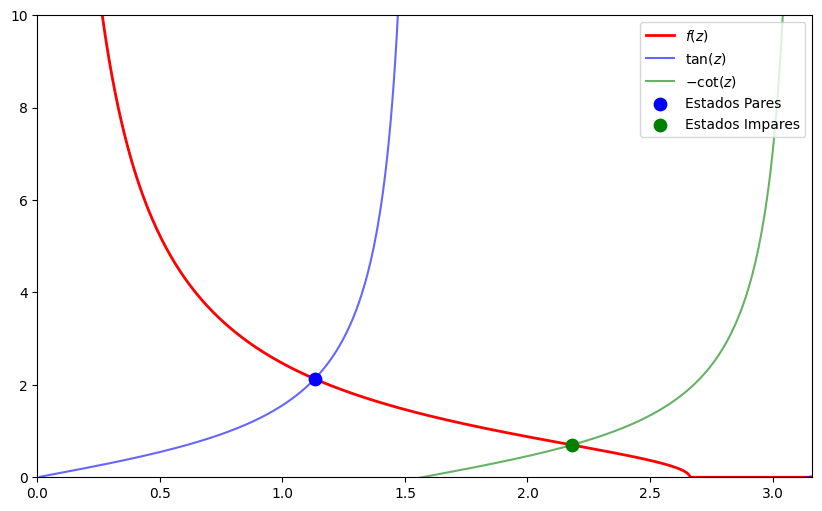

In [ ]:
a    = 3e-10     # Width of the potential well [m]
V0   = 3         # Potential of the potential well [eV]
hbar = 197.3e-9  # Planck constant divided by 2pi multiplied by speed of light [eV*m]
me   = 5.11e5    # Energy of the mass of the electron [eV]
z0   = (a/hbar) * np.sqrt(2 * me * V0)


def f(z, z0):
    # np.maximum avoids negative values inside the sqrt
    return np.sqrt(np.maximum((z0/z)**2 - 1, 0))

def derivative(z, z0):
    f_val = np.maximum(f(z, z0), 1e-15)
    return -(z0**2) / (z**3 * f_val)

def Newton_Raphson(type, z0, z, iteraciones):
    for i in range(iteraciones):
        if type == 'pair':
            g  = np.tan(z) - f(z, z0)
            dg = (1/np.cos(z)**2) - derivative(z, z0)
        elif type == 'odd':
            g  = -1/np.tan(z) - f(z, z0)
            dg = (1/np.sin(z)**2) - derivative(z, z0)
        z = z - (g/dg)
    return z

def seed(type, z0, divisions):

    if type == 'pair':
        z_scan = np.linspace(0.05, z0 - 0.05, divisions)
        g = np.tan(z_scan) - f(z_scan, z0)#The seed for pair values is tan(z)

    elif type == 'odd':
        z_scan = np.linspace(np.pi/2 + 0.05, z0 - 0.001, divisions)
        g = -1/np.tan(z_scan) - f(z_scan, z0)#The seed for odd values is -1/tan(z)

    sign  = np.where(np.diff(np.sign(g)))[0]#We look for the point where the sign of the function changes, the 0 for that we use np.sig and np.diff
    seeds = []

    for idx in sign:
        if abs(g[idx] - g[idx+1]) < 5.0:
            seeds.append((z_scan[idx] + z_scan[idx+1]) / 2)

    return np.array(seeds)

def get_energy(type, semillas, z0_eff, me_eff):
    # Returns the energy of the first valid root found inside the well

    for s in semillas:
        z_sol = Newton_Raphson(type, z0_eff, s, 50)
        if 0 < z_sol < z0_eff:
            return (hbar * z_sol / a)**2 / (2 * me_eff)

    return np.nan

semillas_par = seed('pair', z0, 10000)
semillas_imp = seed('odd',  z0, 10000)

raices_par = []
raices_imp = []

for s in semillas_par:

    z_sol = Newton_Raphson('pair', z0, s, 50)
    if 0 < z_sol < z0:
        raices_par.append(z_sol)

for s in semillas_imp:

    z_sol = Newton_Raphson('odd', z0, s, 50)
    if 0 < z_sol < z0:
        raices_imp.append(z_sol)

z_arr = np.linspace(0.01, np.pi*2, 1000)
y_tan = np.ma.masked_where(np.abs(np.tan(z_arr)) > 20, np.tan(z_arr))
y_cot = np.ma.masked_where(np.abs(1/np.tan(z_arr)) > 20, -1/np.tan(z_arr))

plt.figure(figsize=(10, 6))
plt.plot(z_arr, f(z_arr, z0), color='red',   lw=2,   label=r'$f(z)$')
plt.plot(z_arr, y_tan,        color='blue',  alpha=0.6, label=r'$\tan(z)$')
plt.plot(z_arr, y_cot,        color='green', alpha=0.6, label=r'$-\cot(z)$')
plt.scatter(raices_par, [f(r, z0) for r in raices_par], color='blue',  s=80, zorder=5, label='Estados Pares')
plt.scatter(raices_imp, [f(r, z0) for r in raices_imp], color='green', s=80, zorder=5, label='Estados Impares')
plt.ylim(0, 10)
plt.xlim(0, z0+0.5)
plt.legend()
plt.show()


In [ ]:

print("Energy levels:")
for i, z_sol in enumerate(raices_par):
    E = (hbar * z_sol / a)**2 / (2 * me)
    print(f"  E_par{i+1}   = {E:.4f} eV")

for i, z_sol in enumerate(raices_imp):
    E = (hbar * z_sol / a)**2 / (2 * me)
    print(f"  E_impar{i+1} = {E:.4f} eV")

Energy levels:
  E_par1   = 0.5421 eV
  E_impar1 = 2.0138 eV


2-Find the correct effective mass $m^*= x·m_{e}$, where me is the electron

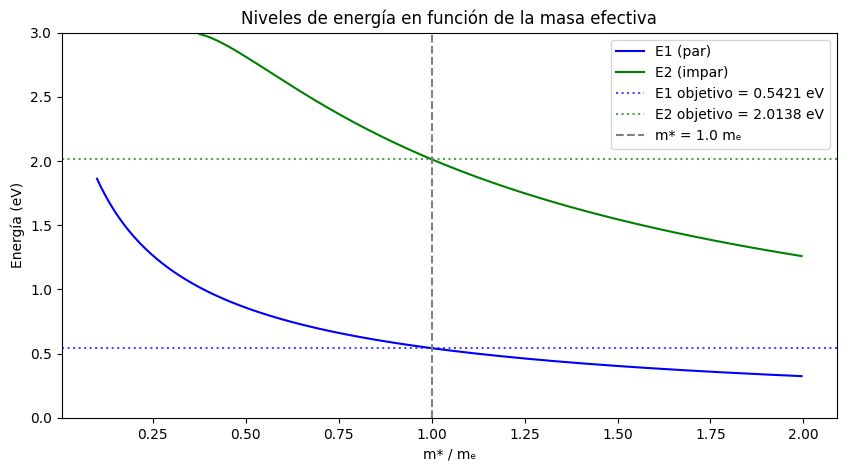

In [ ]:

E1_target = (hbar * raices_par[0] / a)**2 / (2 * me)
E2_target = (hbar * raices_imp[0] / a)**2 / (2 * me)

masses  = np.arange(0.1, 2.0, 0.005)
E1_list = []
E2_list = []

for mass in masses:
    me_eff = mass * 5.11e5
    z0_eff = (a / hbar) * np.sqrt(2 * me_eff * V0)
    E1_list.append(get_energy('pair', seed('pair', z0_eff, 5000), z0_eff, me_eff))
    E2_list.append(get_energy('odd',  seed('odd',  z0_eff, 5000), z0_eff, me_eff))


plt.figure(figsize=(10, 5))
plt.plot(masses, E1_list, color='blue',  label='E1 (par)')
plt.plot(masses, E2_list, color='green', label='E2 (impar)')
plt.axhline(E1_target, color='blue',  linestyle=':', alpha=0.7, label=f'E1 objetivo = {E1_target:.4f} eV')
plt.axhline(E2_target, color='green', linestyle=':', alpha=0.7, label=f'E2 objetivo = {E2_target:.4f} eV')
plt.axvline(1.0, color='gray', linestyle='--', label='m* = 1.0 mₑ')
plt.xlabel('m* / mₑ')
plt.ylabel('Energía (eV)')
plt.title('Niveles de energía en función de la masa efectiva')
plt.ylim(0, V0)
plt.legend()
plt.show()

3-Explain the relationship between energy levels and the depth of the potential well.

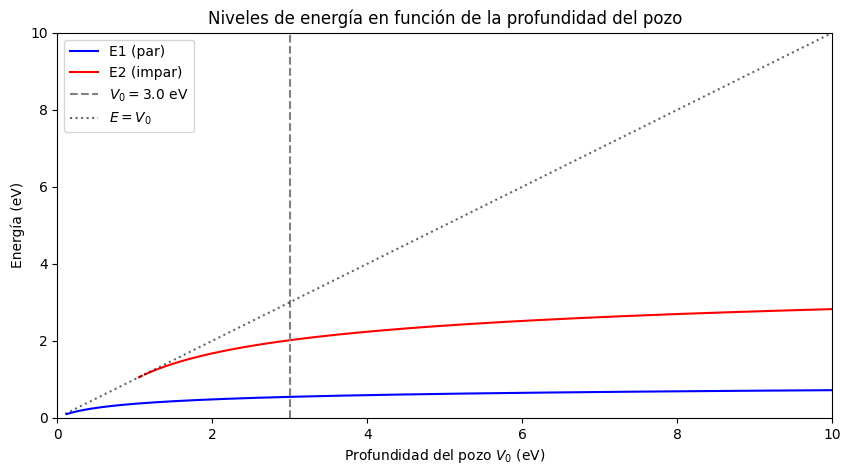

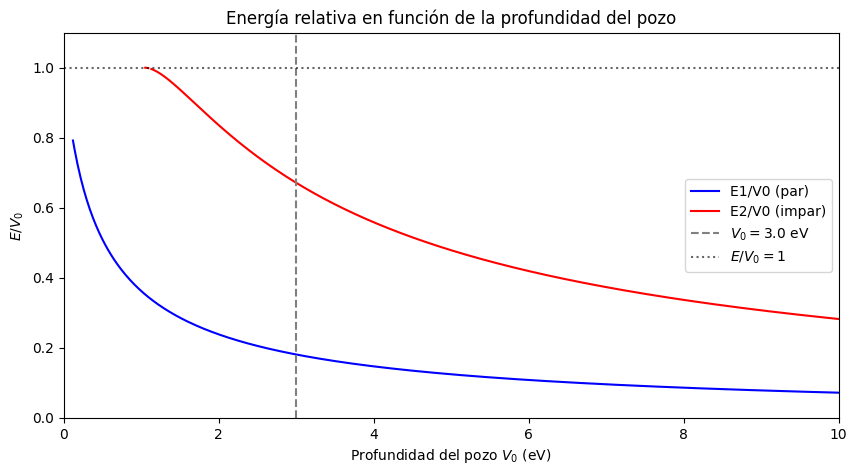

Relationship between energy levels and the depth of the well:
- When V0 increases, the allowed energy levels increase in absolute value.
- However, the ratio E/V0 decreases, which means the levels grow slower than the depth of the well.
- A deeper well can contain more bound states.
- The allowed energies always remain below V0, because only states with E < V0 are bound.


In [ ]:
# 3-Explain the relationship between energy levels and the depth of the potential well.

#We create an array with different values of the potential well depth
V0_values = np.linspace(0.1, 10.0, 500)

E1_V0_list = []
E2_V0_list = []

for V0_val in V0_values:

    #For each value of V0 we calculate the new z0
    z0_val = (a / hbar) * np.sqrt(2 * me * V0_val)

    #We calculate the seeds for the even and odd states
    seed_pair_val = seed('pair', z0_val, 5000)
    seed_odd_val  = seed('odd', z0_val, 5000)

    #We calculate the first even and odd energy levels
    E1 = get_energy('pair', seed_pair_val, z0_val, me)
    E2 = get_energy('odd', seed_odd_val, z0_val, me)

    E1_V0_list.append(E1)
    E2_V0_list.append(E2)

#We transform the lists into arrays to make calculations easier
E1_V0_array = np.array(E1_V0_list)
E2_V0_array = np.array(E2_V0_list)

plt.figure(figsize=(10, 5))

plt.plot(V0_values, E1_V0_array, label='E1 (par)', color='blue')
plt.plot(V0_values, E2_V0_array, label='E2 (impar)', color='red')

#Original value of the problem
plt.axvline(3.0, color='gray', linestyle='--', label='$V_0 = 3.0$ eV')

#The bound states must be below this line
plt.plot(V0_values, V0_values, color='black', linestyle=':', alpha=0.6, label='$E = V_0$')

plt.xlabel('Profundidad del pozo $V_0$ (eV)')
plt.ylabel('Energía (eV)')
plt.title('Niveles de energía en función de la profundidad del pozo')
plt.ylim(0, 10)
plt.xlim(0, 10)
plt.legend()
plt.show()

#Now we plot the energies divided by V0 to see the relative change
plt.figure(figsize=(10, 5))

plt.plot(V0_values, E1_V0_array / V0_values, label='E1/V0 (par)', color='blue')
plt.plot(V0_values, E2_V0_array / V0_values, label='E2/V0 (impar)', color='red')

plt.axvline(3.0, color='gray', linestyle='--', label='$V_0 = 3.0$ eV')
plt.axhline(1, color='black', linestyle=':', alpha=0.6, label='$E/V_0 = 1$')

plt.xlabel('Profundidad del pozo $V_0$ (eV)')
plt.ylabel('$E/V_0$')
plt.title('Energía relativa en función de la profundidad del pozo')
plt.ylim(0, 1.1)
plt.xlim(0, 10)
plt.legend()
plt.show()

print("Relationship between energy levels and the depth of the well:")
print("- When V0 increases, the allowed energy levels increase in absolute value.")
print("- However, the ratio E/V0 decreases, which means the levels grow slower than the depth of the well.")
print("- A deeper well can contain more bound states.")
print("- The allowed energies always remain below V0, because only states with E < V0 are bound.")